# Experiment 2: Few-Shot Prompt Engineering

**Method:** Provide 2-4 examples in the prompt to guide the model.

**Difference from Zero-Shot:** The model sees examples before classifying.

---

# STEP 1: Check GPU

In [1]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("GPU required!")

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU: Tesla T4
Memory: 15.8 GB


# STEP 2: Install packages

In [2]:
!pip install -q bitsandbytes accelerate

import bitsandbytes
print("Packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 26.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 52.0 MB/s eta 0:00:0000:0100:01
ERROR: pip's dep

# STEP 3: Imports

In [3]:
import json
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from huggingface_hub import login

warnings.filterwarnings('ignore')
random.seed(42)
print("Imports done!")

Imports done!


# STEP 4: HuggingFace Login

In [4]:
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("Logged in!")

Logged in!


# STEP 5: Load Dataset

In [5]:
json_files = glob.glob('/kaggle/input/**/*.json', recursive=True)
print(f"Found: {json_files}")

dataset = None
for f in json_files:
    with open(f, 'r') as file:
        data = json.load(file)
    if isinstance(data, list) and len(data) > 100:
        dataset = data
        print(f"Loaded: {len(dataset)} samples")
        break

if dataset is None:
    raise FileNotFoundError("Dataset not found!")

Found: ['/kaggle/input/solana-dataset/solana_182_final.json']
Loaded: 182 samples


# STEP 6: Split Dataset (same as Zero-Shot)

In [6]:
by_type = defaultdict(list)
for sample in dataset:
    by_type[sample['vulnerability_type']].append(sample)

train_data, val_data, test_data = [], [], []

for vtype, samples in by_type.items():
    labels = [s['label'] for s in samples]
    train_s, temp_s = train_test_split(samples, test_size=0.2, stratify=labels, random_state=42)
    temp_labels = [s['label'] for s in temp_s]
    val_s, test_s = train_test_split(temp_s, test_size=0.5, stratify=temp_labels, random_state=42)
    
    train_data.extend(train_s)
    val_data.extend(val_s)
    test_data.extend(test_s)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

Train: 140 | Val: 21 | Test: 21


# STEP 7: Load Model

In [7]:
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading model...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN
)
model.eval()

print(f"Model loaded: {MODEL_ID}")

Loading model...


tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

Model loaded: meta-llama/Llama-3.1-8B-Instruct


# STEP 8: Extract Code Function

In [8]:
def extract_code(sample):
    """Extract code from sample."""
    text = sample.get('text', '')
    
    if '<|start_header_id|>user<|end_header_id|>' in text:
        start = text.find('<|start_header_id|>user<|end_header_id|>') + len('<|start_header_id|>user<|end_header_id|>')
        end = text.find('<|eot_id|><|start_header_id|>assistant')
        if end > start:
            code = text[start:end].strip()
            code = code.replace('```rust', '').replace('```', '').strip()
            return code
    
    return sample.get('code', text[:1500])

print("Extract function ready!")

Extract function ready!


# STEP 9: Prepare Few-Shot Examples
* Get balanced examples from training data
* 1 VULNERABLE + 1 SAFE per vulnerability type

In [9]:


few_shot_examples = []

# Get examples from training data (NOT test data!)
vuln_samples = [s for s in train_data if s['label'] == 'VULNERABLE'][:2]
safe_samples = [s for s in train_data if s['label'] == 'SAFE'][:2]

# Combine: VULN, SAFE, VULN, SAFE (alternating)
few_shot_examples = []
for v, s in zip(vuln_samples, safe_samples):
    few_shot_examples.append(v)
    few_shot_examples.append(s)

print(f"Few-shot examples: {len(few_shot_examples)}")
for ex in few_shot_examples:
    print(f"  - {ex['vulnerability_type']}: {ex['label']}")

Few-shot examples: 4
  - Integer Flow: VULNERABLE
  - Integer Flow: SAFE
  - Integer Flow: VULNERABLE
  - Integer Flow: SAFE


# STEP 10: Build Few-Shot Examples Text

In [10]:
def build_examples_text(examples):
    """Build the few-shot examples section."""
    text = ""
    for i, ex in enumerate(examples, 1):
        code = extract_code(ex)[:300]  # Short code snippets
        label = ex['label']
        text += f"\n### Example {i}:\n```rust\n{code}\n```\nClassification: {label}\n"
    return text

examples_text = build_examples_text(few_shot_examples)
print(f"Examples text length: {len(examples_text)} chars")
print(examples_text[:500] + "...")

Examples text length: 1412 chars

### Example 1:
```rust
You are a Solana smart contract security analyzer. Analyze the following Rust code for arithmetic overflow/underflow vulnerabilities.

Code:
pub fn process_withdraw(
    program_id: &Pubkey,
    accounts: &[AccountInfo],
    amount: u64,
) -> ProgramResult {
    let account_info_iter = &mut accounts
```
Classification: VULNERABLE

### Example 2:
```rust
You are a Solana smart contract security analyzer. Analyze the following Rust code for arithmetic overflow/underflow vul...


# STEP 11: Few-Shot Prediction Function

In [11]:
def predict_few_shot(sample, examples_text):
    """Classify using few-shot prompting with examples."""
    code = extract_code(sample)
    
    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a Solana smart contract security auditor.
Learn from the examples below, then classify the target code.
Respond with exactly one word: VULNERABLE or SAFE.<|eot_id|><|start_header_id|>user<|end_header_id|>

## Examples:{examples_text}

## Target Code to Classify:
```rust
{code[:600]}
```

Based on the patterns in the examples, is this code VULNERABLE or SAFE?<|eot_id|><|start_header_id|>assistant<|end_header_id|>

"""
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2000)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    response = response.strip().upper()
    
    if 'VULNERABLE' in response:
        return 'VULNERABLE'
    elif 'SAFE' in response:
        return 'SAFE'
    else:
        return 'VULNERABLE'

# Test
test_sample = test_data[0]
pred = predict_few_shot(test_sample, examples_text)
print(f"Prediction: {pred}")
print(f"Actual: {test_sample['label']}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Prediction: VULNERABLE
Actual: SAFE


# STEP 12: Run Evaluation

In [12]:
print("Running Few-Shot evaluation...")
print(f"Test samples: {len(test_data)}")
print(f"Few-shot examples: {len(few_shot_examples)}")
print("-" * 40)

results = []
for sample in tqdm(test_data, desc="Evaluating"):
    pred = predict_few_shot(sample, examples_text)
    results.append({
        'vulnerability_type': sample['vulnerability_type'],
        'ground_truth': sample['label'],
        'prediction': pred,
        'correct': sample['label'] == pred
    })

print(f"\nDone! Correct: {sum(r['correct'] for r in results)}/{len(results)}")

Running Few-Shot evaluation...
Test samples: 21
Few-shot examples: 4
----------------------------------------


Evaluating: 100%|██████████| 21/21 [00:15<00:00,  1.33it/s]


Done! Correct: 13/21


# STEP 13: Show Detailed Results

In [13]:
print("\nDetailed Results:")
print("-" * 60)
for i, r in enumerate(results, 1):
    status = "✓" if r['correct'] else "✗"
    print(f"{i:2}. {r['vulnerability_type']:<18} True: {r['ground_truth']:<12} Pred: {r['prediction']:<12} {status}")
print("-" * 60)


Detailed Results:
------------------------------------------------------------
 1. Integer Flow       True: SAFE         Pred: VULNERABLE   ✗
 2. Integer Flow       True: SAFE         Pred: VULNERABLE   ✗
 3. Integer Flow       True: VULNERABLE   Pred: VULNERABLE   ✓
 4. Type Confusion     True: SAFE         Pred: SAFE         ✓
 5. Type Confusion     True: SAFE         Pred: SAFE         ✓
 6. Type Confusion     True: VULNERABLE   Pred: VULNERABLE   ✓
 7. DoS                True: SAFE         Pred: VULNERABLE   ✗
 8. DoS                True: SAFE         Pred: SAFE         ✓
 9. DoS                True: VULNERABLE   Pred: SAFE         ✗
10. Bump Seed          True: SAFE         Pred: VULNERABLE   ✗
11. Bump Seed          True: SAFE         Pred: SAFE         ✓
12. Bump Seed          True: VULNERABLE   Pred: SAFE         ✗
13. Unchecked Calls    True: SAFE         Pred: SAFE         ✓
14. Unchecked Calls    True: SAFE         Pred: SAFE         ✓
15. Unchecked Calls    True: VULNERABL

# STEP 14: Calculate Metrics

In [14]:
all_gt = [r['ground_truth'] for r in results]
all_pred = [r['prediction'] for r in results]

accuracy = accuracy_score(all_gt, all_pred)
precision = precision_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
recall = recall_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)
f1 = f1_score(all_gt, all_pred, pos_label='VULNERABLE', zero_division=0)

print("=" * 50)
print("EXPERIMENT 2: FEW-SHOT RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-Score:  {f1:.2%}")
print("=" * 50)

EXPERIMENT 2: FEW-SHOT RESULTS
Accuracy:  61.90%
Precision: 44.44%
Recall:    57.14%
F1-Score:  50.00%


# STEP 15: Per-Vulnerability Metrics

In [15]:
print("\nPer-Vulnerability Type:")
print("-" * 60)

metrics_by_type = {}
for vtype in sorted(set(r['vulnerability_type'] for r in results)):
    type_results = [r for r in results if r['vulnerability_type'] == vtype]
    gt = [r['ground_truth'] for r in type_results]
    pred = [r['prediction'] for r in type_results]
    
    acc = accuracy_score(gt, pred)
    metrics_by_type[vtype] = {'accuracy': acc, 'count': len(type_results)}
    print(f"{vtype:<20}: {acc:.2%} ({len(type_results)} samples)")

print("-" * 60)
avg_acc = np.mean([m['accuracy'] for m in metrics_by_type.values()])
print(f"{'AVERAGE':<20}: {avg_acc:.2%}")


Per-Vulnerability Type:
------------------------------------------------------------
Bump Seed           : 33.33% (3 samples)
CPI                 : 66.67% (3 samples)
DoS                 : 33.33% (3 samples)
Integer Flow        : 33.33% (3 samples)
Missing Key Check   : 66.67% (3 samples)
Type Confusion      : 100.00% (3 samples)
Unchecked Calls     : 100.00% (3 samples)
------------------------------------------------------------
AVERAGE             : 61.90%


# STEP 16: Confusion Matrix

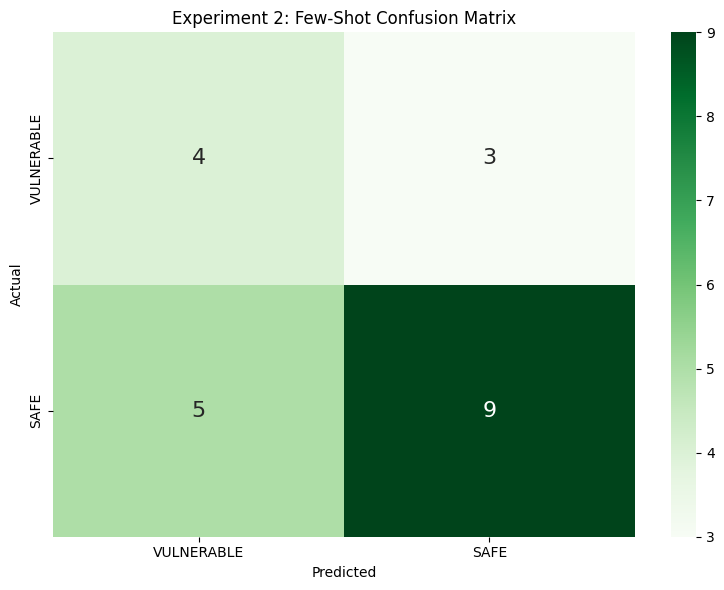


TP: 4 | FN: 3
FP: 5 | TN: 9


In [16]:
cm = confusion_matrix(all_gt, all_pred, labels=['VULNERABLE', 'SAFE'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['VULNERABLE', 'SAFE'],
            yticklabels=['VULNERABLE', 'SAFE'],
            annot_kws={'size': 16})
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Experiment 2: Few-Shot Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/cm_few_shot.png', dpi=150)
plt.show()

print(f"\nTP: {cm[0,0]} | FN: {cm[0,1]}")
print(f"FP: {cm[1,0]} | TN: {cm[1,1]}")

# STEP 17: Save Results

In [17]:
pd.DataFrame(results).to_csv('/kaggle/working/results_few_shot.csv', index=False)

summary = {
    'experiment': 'Few-Shot Prompt Engineering',
    'model': MODEL_ID,
    'num_examples': len(few_shot_examples),
    'dataset_size': len(dataset),
    'test_size': len(test_data),
    'results': {
        'accuracy': round(accuracy, 4),
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1_score': round(f1, 4)
    },
    'confusion_matrix': {
        'TP': int(cm[0,0]), 'FN': int(cm[0,1]),
        'FP': int(cm[1,0]), 'TN': int(cm[1,1])
    },
    'per_vulnerability': metrics_by_type
}

with open('/kaggle/working/summary_few_shot.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  - results_few_shot.csv")
print("  - summary_few_shot.json")
print("  - cm_few_shot.png")

Saved:
  - results_few_shot.csv
  - summary_few_shot.json
  - cm_few_shot.png
